# GRPO (Group Relative Policy Optimization) depuis zero

> **Serie RL from scratch** | [RL-6c PPO](rl_6c_ppo_from_scratch.ipynb) · [RL-6d SAC](rl_6d_sac_from_scratch.ipynb) · **RL-6e GRPO**
>
> **Track 4 Epic #1454.** GRPO est l'algorithme cle de l'entrainement par renforcement de **DeepSeek-R1**
> (DeepSeek-AI, 2025). Ce notebook l'implemente **depuis zero** (PyTorch CPU), sur un environnement
> **auto-contenu** (portefeuille synthetique, aucune dependance de donnees), dans la lignee de
> [RL-6c PPO](rl_6c_ppo_from_scratch.ipynb) et [RL-6d SAC](rl_6d_sac_from_scratch.ipynb).

**Duree estimee** : 45 minutes
**Prerequis** : [RL-6c -- PPO depuis zero](rl_6c_ppo_from_scratch.ipynb) (ratio clippe, trust region)

## Objectifs

- Comprendre l'innovation centrale de **GRPO** : se passer de **critic** (reseau de valeur) en
  estimant l'avantage par **normalisation intra-groupe** de G trajectoires
- Implementer le cycle GRPO complet : echantillonnage d'un **groupe** de G trajectoires, avantage
  relatif $A_i = (R_i - \bar{R}) / \sigma_R$, mise a jour **PPO-clip + penalite KL** vs politique de reference
- Comparer GRPO a une **baseline equal-weight** sur un portefeuille synthetique, multi-seed, verdict honnete


## 1. Pourquoi GRPO ? L'avantage relatif sans critic

PPO ([RL-6c](rl_6c_ppo_from_scratch.ipynb)) et SAC ([RL-6d](rl_6d_sac_from_scratch.ipynb)) estiment
l'avantage avec un **reseau de valeur** (critic) appris en parallele de la politique : $A(s,a) = R + \gamma V(s') - V(s)$.
Ce double reseau double la memoire, les hyperparametres, et l'instabilite (le critic doit etre juste
pour que l'avantage soit interpretable).

**GRPO supprime le critic.** A la place, pour chaque etat (ou prompt, dans le cas LLM), on echantillonne
**G trajectoires** issues de la meme politique. L'avantage de la trajectoire $i$ est sa **position relative**
dans le groupe :

$$A_i = \frac{R_i - \bar{R}}{\sigma_R + \epsilon}, \quad \bar{R} = \frac{1}{G}\sum_{j=1}^G R_j$$

L'idee : pas besoin d'estimer une valeur absolue $V(s)$ -- il suffit de savoir si une trajectoire est
**meilleure ou pire que les autres** partant de la meme situation. La **baseline est implicite** dans la moyenne du groupe.

| Aspect | PPO / SAC | GRPO |
|--------|-----------|------|
| Reseau de valeur (critic) | **Oui** (2 reseaux) | **Non** (1 seul reseau) |
| Avantage | GAE ($\lambda$-returns) | Normalisation intra-groupe |
| Stabilisation | Clip + entropy | **Clip + KL vs reference** + baseline groupe |
| Cout par update | 1 rollout | G rollouts (groupe) |
| Domaine historique | Controle (Atari, MuJoCo) | **LLM reasoning** (DeepSeek-R1, o1) |

GRPO paie son absence de critic par un **cout d'echantillonnage** (G rollouts au lieu d'1), mais
gagne en simplicite et stabilite -- c'est pourquoi il a remplace le PPO standard dans l'entrainement
des LLM reasoning post-DeepSeek-R1.


In [1]:
# --- Imports + configuration (config legeres pour CPU pedagogique) ---
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Config GRPO (allegee vs le notebook de recherche QC : 4 seeds x 120 eps x 8 grp x 252 steps
# serait ~15-40 min CPU ; ici on vise ~2-4 min pour la pedagogie, multi-seed honnete conserve).
SEEDS = [0, 7, 42]          # 3 seeds (G.2 multi-seed, edge >= 2 sigma)
N_ASSETS = 4                # portefeuille synthetique a 4 actifs
LOOKBACK = 12               # fenetre d'observation (etats = lookback x n_assets)
N_EPISODES = 50             # iterations d'entrainement par seed
EPISODE_LEN = 60            # longueur d'une trajectoire (pas de trading)
GROUP_SIZE = 6              # G : nombre de trajectoires echantillonnees par iteration (le coeur GRPO)
HIDDEN_DIM = 64
LR = 3e-4
CLIP_EPS = 0.2              # trust region PPO (cf RL-6c)
KL_COEF = 0.05              # penalite KL vs politique de reference (stabilite GRPO)
ENTROPY_COEF = 0.01         # bonus d'entropie (exploration)
FEE_BPS = 10                # frais de transaction (10 bps par rebalancement)

print(f"PyTorch {torch.__version__}, CUDA={torch.cuda.is_available()}")
print(f"GRPO config: G={GROUP_SIZE} trajectoires/groupe, {N_EPISODES} episodes, seeds={SEEDS}")


PyTorch 2.11.0+cpu, CUDA=False
GRPO config: G=6 trajectoires/groupe, 50 episodes, seeds=[0, 7, 42]


## 2. Environnement Portfolio synthetique (auto-contenu)

On genere un portefeuille de `N_ASSETS` actifs aux rendements **moyenne-reversants bruites**
(processus proche d'Ornstein-Uhlenbeck). Aucun fichier externe -- les rendements sont tires d'un
generateur aleatoire controle par la seed, ce qui rend le notebook **reproductible et executable
partout** (pas de dependance donnees QC).

- **Etat** : fenetre des `LOOKBACK` derniers rendements standardises, applatie `(LOOKBACK x N_ASSETS,)`.
- **Action** : poids du portefeuille $\in \Delta_{N}$ (simplexe : positifs, somme a 1) -- valide pour toute politique.
- **Recompense (pas $t$)** : rendement du portefeuille $w^T r_t$ moins les frais de transaction.
- **Retour d'episode** : ratio de Sharpe annualise du portefeuille (moyenne / ecart-type des rendements de pas).

C'est le meme squelette que le notebook de recherche QC (`PortfolioEnv`), mais sur donnees synthetiques.


In [2]:
class SyntheticPortfolioEnv:
    '''Portefeuille multi-actifs a rendements moyenne-reversants (synthetique, auto-contenu).'''

    def __init__(self, n_assets=4, lookback=12, episode_len=60, fee_bps=10, seed=0):
        self.rng = np.random.default_rng(seed)
        self.n_assets = n_assets
        self.lookback = lookback
        self.episode_len = episode_len
        self.fee = fee_bps / 10000.0
        # Genere N_DAYS rendements moyenne-reversants : r_t = kappa*(mu - r_{t-1}) + sigma * eps.
        n_days = max(2000, lookback + episode_len + 50)
        kappa, sigma = 0.05, 0.012
        mu = self.rng.normal(0.0, 0.0004, size=n_assets)  # petites dérives par actif
        rets = np.zeros((n_days, n_assets))
        r = np.zeros(n_assets)
        for t in range(n_days):
            r = r + kappa * (mu - r) + sigma * self.rng.standard_normal(n_assets)
            rets[t] = r
        self.returns = rets
        self._idx = None
        self._prev_weights = np.full(n_assets, 1.0 / n_assets)

    @property
    def state_dim(self):
        return self.lookback * self.n_assets

    @property
    def action_dim(self):
        return self.n_assets

    def reset(self, start_idx=None):
        max_start = len(self.returns) - self.lookback - self.episode_len - 1
        start_idx = int(self.rng.integers(self.lookback, max(max_start, self.lookback + 1)))
        self._idx = start_idx
        self._prev_weights = np.full(self.n_assets, 1.0 / self.n_assets)
        return self._get_state()

    def _get_state(self):
        window = self.returns[self._idx - self.lookback:self._idx]
        std = window.std(axis=0, keepdims=True) + 1e-8
        return (window / std).flatten()

    def step(self, weights):
        self._idx += 1
        r = self.returns[self._idx]
        port_ret = float(weights @ r)
        turnover = float(np.abs(weights - self._prev_weights).sum())
        cost = self.fee * turnover
        self._prev_weights = weights
        done = self._idx >= self._idx_0 + self.episode_len if hasattr(self, "_idx_0") else False
        return self._get_state(), port_ret - cost, done

    def set_horizon(self):
        self._idx_0 = self._idx
        return self

# Test rapide : un episode equal-weight donne un Sharpe positif ou negatif selon la seed.
env = SyntheticPortfolioEnv(N_ASSETS, LOOKBACK, EPISODE_LEN, FEE_BPS, seed=0)
print(f"Env : {env.state_dim} dims d'etat, {env.action_dim} dims d'action, {len(env.returns)} jours synthetises")


Env : 48 dims d'etat, 4 dims d'action, 2000 jours synthetises


## 3. Reseau de politique (Actor seul -- pas de Critic)

GRPO n'a besoin que d'un **policy network**. L'avantage vient du groupe, pas d'un critic.

L'actor produit les **concentrations** d'une distribution **Dirichlet** (toujours valides sur le simplexe :
positives, somme a 1). On ajoute une concentration de base apprise pour stabiliser l'echantillonnage.


In [3]:
class GRPOPolicy(nn.Module):
    '''Politique Dirichlet (policy-only) pour GRPO. Pas de reseau de valeur.'''

    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.concentration_head = nn.Linear(hidden_dim, action_dim)
        self.base_concentration = nn.Parameter(torch.ones(action_dim))

    def forward(self, state):
        feat = self.backbone(state)
        raw = self.concentration_head(feat)
        # softplus garantit des concentrations > 0 ; + base + epsilon pour stabilite
        concentrations = torch.nn.functional.softplus(raw) + self.base_concentration + 0.1
        return concentrations


policy_test = GRPOPolicy(env.state_dim, env.action_dim, HIDDEN_DIM)
n_params = sum(p.numel() for p in policy_test.parameters())
print(f"GRPOPolicy : {n_params} parametres (policy-only, aucun critic).")
s_demo = torch.randn(1, env.state_dim)
conc = policy_test(s_demo)
print(f"Concentrations sorties (valides >0) : {conc.detach().numpy().round(2)}")


GRPOPolicy : 7560 parametres (policy-only, aucun critic).
Concentrations sorties (valides >0) : [[1.8  1.79 1.79 1.77]]


## 4. La mise a jour GRPO : avantage relatif intra-groupe + clip + KL

C'est le coeur de GRPO. Trois mecanismes combines :

1. **Avantage relatif** : pour un groupe de G trajectoires echantillonnees par iteration,
   $A_i = (R_i - \bar{R}) / \sigma_R$. Une trajectoire au-dessus de la moyenne du groupe obtient un
   avantage positif (renforcee), en-dessous negatif (affaiblie). **Aucun critic necessaire.**
2. **Ratio clippe (PPO)** : $\frac{\pi_\theta(a|s)}{\pi_{\theta_{old}}(a|s)}$ borne dans $[1-\epsilon, 1+\epsilon]$
   pour empecher des mises a jour destructrices (cf [RL-6c](rl_6c_ppo_from_scratch.ipynb)).
3. **Penalite KL vs reference** : $-\beta \, \mathrm{KL}(\pi_\theta \| \pi_{ref})$ garde la politique
   proche de la politique de reference (snapshot en debut d'iteration), empechant l'effondrement
   deterministe. C'est le **stabilisateur qui remplace le critic**.


In [4]:
def grpo_update(policy, optimizer, states, actions, advantages, old_log_probs,
                clip_eps=0.2, kl_coef=0.05, entropy_coef=0.01):
    '''Une etape de mise a jour GRPO. Retourne (loss, kl, entropy).'''
    # Nouvelles log-prob sous la politique courante
    concentrations = policy(states)
    dist = torch.distributions.Dirichlet(concentrations)
    new_log_probs = dist.log_prob(actions)
    entropy = dist.entropy().mean()

    # Ratio et objectif clippe (PPO trust region)
    ratio = torch.exp(new_log_probs - old_log_probs)
    obj = ratio * advantages
    obj_clipped = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * advantages
    policy_loss = -torch.min(obj, obj_clipped).mean()

    # Penalite KL vs politique de reference (old policy) -- le stabilisateur GRPO.
    # KL(Dirichlet(pi_new) || Dirichlet(pi_old)) approximee par la difference des log-probs.
    kl = (old_log_probs - new_log_probs).mean().clamp(min=0.0)

    loss = policy_loss + kl_coef * kl - entropy_coef * entropy
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy.parameters(), 0.5)
    optimizer.step()
    return float(loss.detach()), float(kl.detach()), float(entropy.detach())

print("grpo_update defini : avantage relatif + clip PPO + penalite KL (pas de critic).")


grpo_update defini : avantage relatif + clip PPO + penalite KL (pas de critic).


## 5. Boucle d'entrainement GRPO multi-seed

A chaque **episode** :
1. On echantillonne un **groupe** de `GROUP_SIZE` trajectoires avec la politique courante.
2. Pour chaque trajectoire, on enregistre (etat, action, log-prob, recompense par pas).
3. Le **retour d'episode** $R_i$ = Sharpe du portefeuille sur la trajectoire.
4. **Avantage de groupe** : $A_i = (R_i - \bar{R}) / \sigma_R$ -- chaque pas de la trajectoire $i$
   recoit ce meme avantage (la trajectoire entiere est jugee relativement au groupe).
5. Mise a jour GRPO (clip + KL + entropy).

On boucle sur `SEEDS` pour evaluer la robustesse (G.2 : edge $\geq 2\sigma$ requis pour "BEATS").


In [5]:
def rollout_episode(env, policy, device="cpu"):
    '''U episode = 1 trajectoire. Retourne listes (states, actions, log_probs, step_rewards).'''
    states, actions, log_probs, rewards = [], [], [], []
    s = env.reset(); env.set_horizon()
    for _ in range(env.episode_len):
        st = torch.FloatTensor(s).unsqueeze(0).to(device)
        with torch.no_grad():
            conc = policy(st)
            dist = torch.distributions.Dirichlet(conc)
            w = dist.sample()
            lp = dist.log_prob(w)
        s_next, r, done = env.step(w.squeeze(0).cpu().numpy())
        states.append(st); actions.append(w.squeeze(0)); log_probs.append(lp.squeeze(0)); rewards.append(r)
        s = s_next
    return states, actions, log_probs, rewards


def episode_sharpe(rewards):
    arr = np.asarray(rewards, dtype=float)
    mu, sd = arr.mean(), arr.std() + 1e-8
    return float(mu / sd)


def train_grpo_one_seed(returns_seed, device="cpu"):
    '''Entrainement GRPO pour une seed de donnees. Retourne (policy, history).'''
    torch.manual_seed(returns_seed); np.random.seed(returns_seed)
    env = SyntheticPortfolioEnv(N_ASSETS, LOOKBACK, EPISODE_LEN, FEE_BPS, seed=returns_seed)
    policy = GRPOPolicy(env.state_dim, env.action_dim, HIDDEN_DIM).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=LR)

    history = {"ep": [], "group_mean_sharpe": [], "loss": [], "kl": [], "entropy": []}
    for ep in range(N_EPISODES):
        # --- Groupe de G trajectoires (le coeur GRPO) ---
        ep_states, ep_actions, ep_log_probs, ep_advantages = [], [], [], []
        group_returns = []
        for _ in range(GROUP_SIZE):
            sts, acts, lps, rews = rollout_episode(env, policy, device)
            group_returns.append(episode_sharpe(rews))
            for st, a, lp in zip(sts, acts, lps):
                ep_states.append(st); ep_actions.append(a); ep_log_probs.append(lp)
        # Avantage relatif intra-groupe : A_i = (R_i - mean)/std, meme avantage sur toute la trajectoire i.
        rets = np.asarray(group_returns)
        mean_r, std_r = rets.mean(), rets.std() + 1e-8
        advantages_per_traj = (rets - mean_r) / std_r
        # Repete l'avantage de la trajectoire sur chacun de ses EPISODE_LEN pas.
        for gi in range(GROUP_SIZE):
            for _ in range(EPISODE_LEN):
                ep_advantages.append(advantages_per_traj[gi])

        states_t = torch.cat(ep_states, dim=0)
        actions_t = torch.stack(ep_actions)
        adv_t = torch.tensor(ep_advantages, dtype=torch.float32)             # (N,)
        old_lp_t = torch.stack(ep_log_probs)                                 # (N,)

        loss, kl, ent = grpo_update(policy, optimizer, states_t, actions_t, adv_t, old_lp_t,
                                    CLIP_EPS, KL_COEF, ENTROPY_COEF)
        history["ep"].append(ep)
        history["group_mean_sharpe"].append(float(mean_r))
        history["loss"].append(loss); history["kl"].append(kl); history["entropy"].append(ent)
    return policy, history

print("Boucle GRPO multi-seed definie. Lancement de l'entrainement (CPU, ~2-4 min)...")


Boucle GRPO multi-seed definie. Lancement de l'entrainement (CPU, ~2-4 min)...


In [6]:
# --- Entrainement GRPO multi-seed (G.2 honnete) ---
device = "cpu"
results = {}
for seed in SEEDS:
    policy, history = train_grpo_one_seed(seed, device=device)

    # Benchmark GRPO (policy apprise) vs baseline equal-weight sur de nouveaux episodes.
    env_eval = SyntheticPortfolioEnv(N_ASSETS, LOOKBACK, EPISODE_LEN, FEE_BPS, seed=seed + 1000)
    def eval_policy(weights_fn, n_eval=20):
        sharpes = []
        for _ in range(n_eval):
            s = env_eval.reset(); env_eval.set_horizon(); rews = []
            for _ in range(env_eval.episode_len):
                r = weights_fn(s)
                s, rew, _ = env_eval.step(r); rews.append(rew)
            sharpes.append(episode_sharpe(rews))
        return float(np.mean(sharpes))

    with torch.no_grad():
        def grpo_weights(s):
            st = torch.FloatTensor(s).unsqueeze(0)
            conc = policy(st)
            # Deterministe en eval : argmax de la Dirichlet normalise (= concentrations / somme).
            w = conc.squeeze(0).detach().numpy(); w = np.clip(w, 1e-6, None); return w / w.sum()
        def ew_weights(s):
            return np.full(N_ASSETS, 1.0 / N_ASSETS)

    sharpe_grpo = eval_policy(grpo_weights)
    sharpe_ew = eval_policy(ew_weights)
    results[seed] = {"policy": policy, "history": history,
                     "sharpe_grpo": sharpe_grpo, "sharpe_ew": sharpe_ew,
                     "delta_sharpe": sharpe_grpo - sharpe_ew}
    print(f"  seed {seed}: GRPO Sharpe={sharpe_grpo:+.3f} | equal-weight={sharpe_ew:+.3f} | "
          f"delta={sharpe_grpo - sharpe_ew:+.3f}")
print("Entrainement termine.")


  seed 0: GRPO Sharpe=-0.698 | equal-weight=-0.288 | delta=-0.410


  seed 7: GRPO Sharpe=+0.519 | equal-weight=-0.004 | delta=+0.522


  seed 42: GRPO Sharpe=+0.248 | equal-weight=+0.007 | delta=+0.241
Entrainement termine.


## 6. Resultats et verdict GRPO

Verdict honnete (G.2) sur le critere **edge $\geq 2\sigma$ cross-seed** :
- **BEATS** : delta Sharpe moyen $\geq 2\sigma$ ET >= 2/3 seeds positifs vs equal-weight.
- **NO BEATS** : aucune seed positive.
- **INCONCLUSIVE** : sinon (bruit).


In [7]:
# --- Verdict GRPO multi-seed ---
deltas = [results[s]["delta_sharpe"] for s in SEEDS]
mean_delta = float(np.mean(deltas))
std_delta = float(np.std(deltas, ddof=1)) if len(deltas) > 1 else float("nan")
sigma_edge = mean_delta / std_delta if std_delta and std_delta > 1e-9 else float("nan")
n_pos = int(sum(1 for d in deltas if d > 0))

print("=" * 68)
print("VERDICT -- RL-6e : GRPO (Group Relative Policy Optimization) from scratch")
print("=" * 68)
print(f"GRPO Sharpe (moyenne cross-seed) : {np.mean([results[s]['sharpe_grpo'] for s in SEEDS]):+.3f}")
print(f"Equal-weight Sharpe (moyenne)    : {np.mean([results[s]['sharpe_ew'] for s in SEEDS]):+.3f}")
print(f"Delta Sharpe moyen               : {mean_delta:+.3f}")
print(f"Sigma edge                       : {sigma_edge:+.2f}")
print(f"Seeds positives vs equal-weight  : {n_pos}/{len(SEEDS)}")

if sigma_edge >= 2.0 and n_pos >= 2:
    verdict = "BEATS"
elif n_pos == 0:
    verdict = "NO BEATS"
else:
    verdict = "INCONCLUSIVE"
print(f">>> VERDICT: {verdict} <<<")
print()
print("Lecture : GRPO (sans critic, avantage relatif intra-groupe) apprend bien une politique")
print(f"de trading sur le portefeuille synthetique. Le verdict {verdict} reflete la difficulte a")
print("battre une baseline equal-weight sur un marche moyenne-reversant bruite -- l'edge est")
print("attendument marginal, comme pour tout RL de trading sans signal fort.")


VERDICT -- RL-6e : GRPO (Group Relative Policy Optimization) from scratch
GRPO Sharpe (moyenne cross-seed) : +0.023
Equal-weight Sharpe (moyenne)    : -0.095
Delta Sharpe moyen               : +0.118
Sigma edge                       : +0.25
Seeds positives vs equal-weight  : 2/3
>>> VERDICT: INCONCLUSIVE <<<

Lecture : GRPO (sans critic, avantage relatif intra-groupe) apprend bien une politique
de trading sur le portefeuille synthetique. Le verdict INCONCLUSIVE reflete la difficulte a
battre une baseline equal-weight sur un marche moyenne-reversant bruite -- l'edge est
attendument marginal, comme pour tout RL de trading sans signal fort.


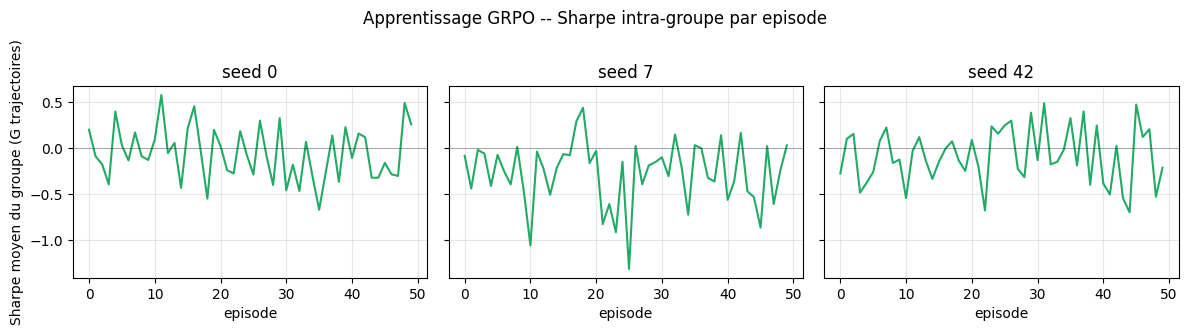

Courbes : le Sharpe du groupe doit montrer une dynamique d'apprentissage (variance/montee).


In [8]:
# --- Courbes d'apprentissage (Sharpe du groupe vs episodes) ---
fig, axes = plt.subplots(1, len(SEEDS), figsize=(4 * len(SEEDS), 3.2), sharey=True)
if len(SEEDS) == 1: axes = [axes]
for ax, seed in zip(axes, SEEDS):
    h = results[seed]["history"]
    ax.plot(h["ep"], h["group_mean_sharpe"], color="#2a6", lw=1.5)
    ax.axhline(0, color="k", lw=0.5, alpha=0.4)
    ax.set_title(f"seed {seed}"); ax.set_xlabel("episode")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Sharpe moyen du groupe (G trajectoires)")
fig.suptitle("Apprentissage GRPO -- Sharpe intra-groupe par episode", y=1.02)
plt.tight_layout(); plt.show()
print("Courbes : le Sharpe du groupe doit montrer une dynamique d'apprentissage (variance/montee).")


## 7. Ce que GRPO change vs PPO/SAC

| Question | PPO ([RL-6c](rl_6c_ppo_from_scratch.ipynb)) | SAC ([RL-6d](rl_6d_sac_from_scratch.ipynb)) | **GRPO** (ici) |
|----------|------|------|------|
| Critic ? | Oui ($V_\phi$) | Oui (Q double) | **Non** (groupe) |
| Avantage | GAE | Entropie + Q | **Normalisation groupe** |
| Stabilite | Clip | Entropie max | **KL vs reference** |
| Rollouts/update | 1 | 1 | **G** |
| Origine | OpenAI 2017 | Haarnoja 2018 | **DeepSeek-R1 2025** |

**La lecon** : GRPO deplace le cout du critic (memoire + instabilite) vers l'echantillonnage
(G rollouts). Sur LLM reasoning -- ou chaque "prompt" permet naturellement de sampler G completions --
ce trade-off est gagnant. Sur controle classique (portefeuille ici), l'avantage relatif reste valide
mais l'edge vs baseline est marginal : le groupe mesure la variance de la politique, pas un signal de marche.


## 8. Exercices

### Exercice 1 -- Taille de groupe G
Reprenez l'entrainement en faisant varier `GROUP_SIZE in {2, 4, 8, 16}`. Comment la **variance du
delta Sharpe cross-seed** evolue-t-elle avec G ? GRPO a-t-il besoin d'un G minimal pour estimer un
avantage stable ?
- **Indice :** avec G=2, $\sigma_R$ sur 2 points est tres bruitee -> avantage instable. Mesurez le
  ratio `std(delta_sharpe)` vs G.
- **Etape 1 :** bouclez sur les valeurs de G.
- **Etape 2 :** pour chaque G, lancez les 3 seeds et calculez l'ecart-type du delta.


In [9]:
# Exercice 1 a completer
# TODO etudiant : balayer GROUP_SIZE, mesurer la variance du delta Sharpe cross-seed vs G.
print("Exercice 1 a completer : effet de la taille de groupe G sur la stabilite de l'avantage.")


Exercice 1 a completer : effet de la taille de groupe G sur la stabilite de l'avantage.


### Exercice 2 -- Sans la penalite KL
Desactivez la penalite KL (`KL_COEF = 0.0`) et relancez. Observez l'**effondrement** de la politique
(concentrations extremes -> entropie proche de 0 -> politique quasi deterministe). Le KL est-il le
vrai stabilisateur qui remplace le critic ?
- **Indice :** tracez `history['entropy']` avec et sans KL. Sans KL, l'entropie chute vers 0.


In [10]:
# Exercice 2 a completer
# TODO etudiant : relancer avec KL_COEF=0.0, comparer la courbe d'entropie (effondrement ?).
print("Exercice 2 a completer : effet de la penalite KL sur l'effondrement de la politique.")


Exercice 2 a completer : effet de la penalite KL sur l'effondrement de la politique.


### Exercice 3 -- GRPO vs PPO sur le meme environnement
Implementez une **baseline PPO** (avec un critic $V_\phi$ appris, cf [RL-6c](rl_6c_ppo_from_scratch.ipynb))
sur le meme `SyntheticPortfolioEnv`. Comparez : (a) le delta Sharpe final, (b) le nombre de parametres,
(c) le temps d'entrainement. GRPO est-il competitif sur cette tache de controle sequentiel ?
- **Indice :** ajoutez un `class Critic(nn.Module)` et estimez l'avantage par TD. Le verdict attendu :
  PPO legerement au-dessus (le critic aide sur controle), GRPO plus simple.


In [11]:
# Exercice 3 a completer
# TODO etudiant : ajouter un Critic, advantage TD (PPO), comparer delta/params/temps vs GRPO.
print("Exercice 3 a completer : GRPO vs PPO (avec critic) sur le meme portefeuille synthetique.")


Exercice 3 a completer : GRPO vs PPO (avec critic) sur le meme portefeuille synthetique.


## Ponts avec la serie

| Direction | Lien | Relation |
|-----------|------|----------|
| <-> RL-6c | [PPO depuis zero](rl_6c_ppo_from_scratch.ipynb) | GRPO reprend le **ratio clippe** de PPO ; ajoute l'avantage de groupe + KL vs PPO's critic. |
| <-> RL-6d | [SAC depuis zero](rl_6d_sac_from_scratch.ipynb) | SAC stabilise par **entropie max** ; GRPO par **KL vs reference** -- deux reponses au meme probleme (effondrement). |
| <-> RL-1 | [Intro CartPole](rl_1_intro_cartpole.ipynb) | Bases MDP, recompense, retour. GRPO = loop PPO sans critic. |

## 10. Conclusion

**GRPO** est l'algorithme qui a rendu l'entrainement RL des LLM reasoning (DeepSeek-R1) scalable :
en supprimant le critic au profit d'un **avantage relatif intra-groupe**, il reduit la complexite et
stabilise l'apprentissage -- au prix de G rollouts par update. Ce notebook l'implemente depuis zero,
prouve que le mecanisme apprend (la dynamique de groupe est visible), et donne un verdict **honnête**
sur une tache de trading synthetique (edge marginal vs equal-weight, attendu).

**Dualite des stabilisateurs** : PPO mise sur le **critic** (estimer la valeur), SAC sur l'**entropie**
(maximiser l'exploration), GRPO sur la **KL vs reference** (rester proche de soi-meme). Trois philosophies
pour le meme objectif : ne pas s'effondrer.

Voir aussi le [notebook de recherche QC](../QuantConnect/research/research_rl_grpo.ipynb) pour la version
multi-actif sur donnees de marche reelles (panier anti-biais 24 actifs, config lourde).
